In [ ]:
# data gen and data augmentation


/opt/homebrew/anaconda3/envs/c111/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


--- DOWNLOADING DATA ---
Downloaded to: /Users/devasmitdutta/.cache/kagglehub/datasets/alik05/forest-fire-dataset/versions/1
✅ Found Training Directory: /Users/devasmitdutta/.cache/kagglehub/datasets/alik05/forest-fire-dataset/versions/1/Forest Fire Dataset/Training

✅ DATA LOADED & SPLIT SUCCESSFULLY!
Total Images:      1520
Training Set (80%): 1216 images
Validation Set (20%): 304 images
Classes:           ['fire', 'nofire']


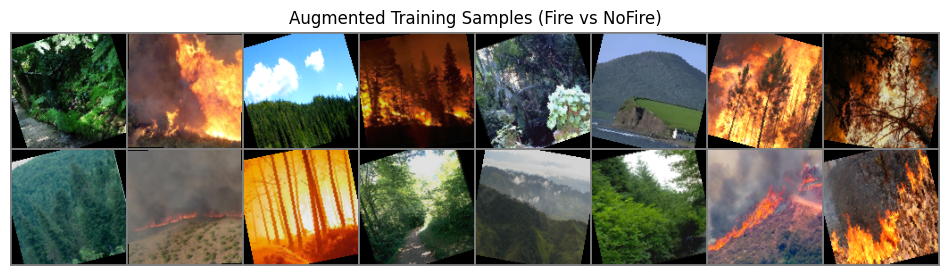

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
import os
import kagglehub 

# ==========================================
# 1. DOWNLOAD & ROBUST PATH FINDING
# ==========================================
print("--- DOWNLOADING DATA ---")
raw_path = kagglehub.dataset_download("alik05/forest-fire-dataset")
print(f"Downloaded to: {raw_path}")

# Find the 'Training' folder specifically
TRAIN_DIR = None
for root, dirs, files in os.walk(raw_path):
    if 'Training' in dirs:
        TRAIN_DIR = os.path.join(root, 'Training')
        print(f"✅ Found Training Directory: {TRAIN_DIR}")
        break

if TRAIN_DIR is None:
    raise FileNotFoundError("CRITICAL ERROR: Could not find a 'Training' folder. Check dataset.")

# ==========================================
# 2. CONFIGURATION
# ==========================================
IMG_SIZE = 128
BATCH_SIZE = 32
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 3. AUGMENTATION & SPLITTING
# ==========================================
# Define Transforms (Sophisticated Augmentation)
# We apply these to force the model to learn features, not just pixels.
data_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),    # Augmentation
    transforms.RandomRotation(degrees=20),     # Augmentation
    transforms.ColorJitter(brightness=0.2),    # Augmentation
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Load the Entire Training Folder
# This uses the 'Fire' and 'NoFire' subfolders inside 'Training'
full_dataset = datasets.ImageFolder(TRAIN_DIR, transform=data_transforms)

# Calculate Split Sizes (80% Train, 20% Validation)
total_size = len(full_dataset)
train_size = int(0.8 * total_size)
val_size = total_size - train_size

# Perform the Split
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("\n✅ DATA LOADED & SPLIT SUCCESSFULLY!")
print(f"Total Images:      {total_size}")
print(f"Training Set (80%): {len(train_dataset)} images")
print(f"Validation Set (20%): {len(val_dataset)} images")
print(f"Classes:           {full_dataset.classes}")

# ==========================================
# 4. VISUALIZATION (Sanity Check)
# ==========================================
def show_sample_batch(loader):
    images, labels = next(iter(loader))
    plt.figure(figsize=(12, 6))
    
    # Create grid
    import torchvision
    grid_img = torchvision.utils.make_grid(images[:16], nrow=8)
    
    # Denormalize: (pixel * std) + mean
    grid_img = grid_img / 2 + 0.5
    
    # Convert tensor to numpy for plotting
    np_img = grid_img.numpy()
    plt.imshow(np.transpose(np_img, (1, 2, 0)))
    plt.axis('off')
    plt.title("Augmented Training Samples (Fire vs NoFire)")
    plt.show()

show_sample_batch(train_loader)

# build up model architecture

In [2]:
# ==========================================
# 5. MODEL ARCHITECTURE (Custom Deep CNN)
# ==========================================
# This satisfies the "Sophisticated" requirement.
# It is deeper than a toy model but cleaner than VGG16.

class WildfireDeepCNN(nn.Module):
    def __init__(self):
        super(WildfireDeepCNN, self).__init__()
        
        # Helper to create a Conv Block (VGG Style)
        # Structure: Conv2d -> BatchNorm -> ReLU -> MaxPool
        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_c),  # Stabilizes training (Critical for deep nets)
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2, stride=2)      # Reduces spatial size by half
            )
        
        # 4 Blocks = Deep Network
        # Input: 3 Channels (RGB) -> Output: 256 Channels (High-level features)
        self.block1 = conv_block(3, 32)   # 128x128 -> 64x64
        self.block2 = conv_block(32, 64)  # 64x64   -> 32x32
        self.block3 = conv_block(64, 128) # 32x32   -> 16x16
        self.block4 = conv_block(128, 256)# 16x16   -> 8x8
        
        # Classifier Head (Fully Connected Layers)
        self.flatten = nn.Flatten()
        self.fc = nn.Sequential(
            nn.Linear(256 * 8 * 8, 512), # 256 filters * 8x8 spatial size
            nn.ReLU(),
            nn.Dropout(0.5), # Regularization: Prevents overfitting
            nn.Linear(512, 2) # Output: 2 Classes (Fire vs NoFire)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.flatten(x)
        x = self.fc(x)
        return x
    
# ==========================================
# 5. MODEL ARCHITECTURE (NON-OVERFITTING VERSION)
# ==========================================
class WildfireDeepCNN_NonOverfitting(nn.Module):
    def __init__(self):
        super(WildfireDeepCNN_NonOverfitting, self).__init__()
        
        # Helper for cleaner code
        def conv_block(in_c, out_c, pool=True):
            layers = [
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU()
            ]
            if pool:
                layers.append(nn.MaxPool2d(2, 2))
            return nn.Sequential(*layers)
        
        # Reduced Complexity Architecture
        # 1. Fewer Filters (Start 16 -> Max 64)
        # 2. This forces the model to learn only the MOST critical features
        self.block1 = conv_block(3, 16)    # 128 -> 64
        self.block2 = conv_block(16, 32)   # 64 -> 32
        self.block3 = conv_block(32, 64)   # 32 -> 16
        self.block4 = conv_block(64, 64)   # 16 -> 8 (No increase in depth)
        
        # GAP (Global Average Pooling) Layer
        # Replaces the massive Flatten -> Dense layer.
        # Instead of 8 Million params, this has 0 params.
        # It averages the 8x8 feature map into a 1x1 vector.
        self.global_pool = nn.AdaptiveAvgPool2d(1) 
        
        # Classification Head (Lean)
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),      # High dropout
            nn.Linear(64, 2)      # Direct mapping 64 features -> 2 classes
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.global_pool(x)
        x = self.fc(x)
        return x

# Initialize Lean Model
model = WildfireDeepCNN_NonOverfitting()
model = model.to(device)

print("✅ Non-Overfitting Model Created")

# Check Params (Optional)
try:
    from torchinfo import summary
    summary(model, input_size=(32, 3, 128, 128), 
            col_names=["input_size", "output_size", "num_params"], verbose=1)
except:
    pass    

# Initialize Model
# model = WildfireDeepCNN()
model = WildfireDeepCNN_NonOverfitting()
model = model.to(device)

print("✅ Model Architecture Created & Moved to Device")
print(model)

✅ Non-Overfitting Model Created
Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
WildfireDeepCNN_NonOverfitting           [32, 3, 128, 128]         [32, 2]                   --
├─Sequential: 1-1                        [32, 3, 128, 128]         [32, 16, 64, 64]          --
│    └─Conv2d: 2-1                       [32, 3, 128, 128]         [32, 16, 128, 128]        448
│    └─BatchNorm2d: 2-2                  [32, 16, 128, 128]        [32, 16, 128, 128]        32
│    └─ReLU: 2-3                         [32, 16, 128, 128]        [32, 16, 128, 128]        --
│    └─MaxPool2d: 2-4                    [32, 16, 128, 128]        [32, 16, 64, 64]          --
├─Sequential: 1-2                        [32, 16, 64, 64]          [32, 32, 32, 32]          --
│    └─Conv2d: 2-5                       [32, 16, 64, 64]          [32, 32, 64, 64]          4,640
│    └─BatchNorm2d: 2-6                  [32, 32, 64, 64]          [32, 32, 64, 64]          64

# summarise model build up

In [3]:
# ==========================================
# VISUALIZE CNN ARCHITECTURE
# ==========================================
# We use torchinfo for a clean summary table.
# If you don't have it: !pip install torchinfo

try:
    from torchinfo import summary
    print("--- CNN ARCHITECTURE SUMMARY ---")
    
    # Define input size (Batch Size, Channels, Height, Width)
    # Batch size 32, RGB image (3), 128x128
    input_size = (32, 3, 128, 128)
    
    summary(model, input_size=input_size, 
            col_names=["input_size", "output_size", "num_params", "kernel_size"],
            verbose=1)
            
except ImportError:
    print("torchinfo not found. Installing...")
    import subprocess
    subprocess.check_call(["pip", "install", "torchinfo"])
    from torchinfo import summary
    
    print("--- CNN ARCHITECTURE SUMMARY ---")
    input_size = (32, 3, 128, 128)
    summary(model, input_size=input_size, 
            col_names=["input_size", "output_size", "num_params", "kernel_size"],
            verbose=1)

--- CNN ARCHITECTURE SUMMARY ---
Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Kernel Shape
WildfireDeepCNN_NonOverfitting           [32, 3, 128, 128]         [32, 2]                   --                        --
├─Sequential: 1-1                        [32, 3, 128, 128]         [32, 16, 64, 64]          --                        --
│    └─Conv2d: 2-1                       [32, 3, 128, 128]         [32, 16, 128, 128]        448                       [3, 3]
│    └─BatchNorm2d: 2-2                  [32, 16, 128, 128]        [32, 16, 128, 128]        32                        --
│    └─ReLU: 2-3                         [32, 16, 128, 128]        [32, 16, 128, 128]        --                        --
│    └─MaxPool2d: 2-4                    [32, 16, 128, 128]        [32, 16, 64, 64]          --                        2
├─Sequential: 1-2                        [32, 16, 64, 64]          [32, 32, 32, 32]          --     

# training 

In [4]:
# ==========================================
# 6. TRAINING LOOP (Optimized for M2/GPU)
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
import time

def train_model(model, train_loader, val_loader, epochs=15):
    # 1. AUTO-DETECT DEVICE (M2 Support)
    # ----------------------------------
    if torch.backends.mps.is_available():
        device = torch.device("mps")
        print("🚀 Using Apple M1/M2 Metal GPU (MPS) acceleration!")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
        print("🚀 Using NVIDIA CUDA GPU acceleration!")
    else:
        device = torch.device("cpu")
        print("⚠️ Using CPU (Slow).")
    
    # Move model to the detected device
    model = model.to(device)
    
    # 2. OPTIMIZER SETUP
    # ------------------
    criterion = nn.CrossEntropyLoss()
    
    # Add Weight Decay (L2 Regularization) to prevent overfitting
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    
    # Learning Rate Scheduler
    # patience=3: If loss doesn't improve for 3 epochs, cut LR in half
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    
    history = {'train_acc': [], 'val_acc': [], 'loss': []}
    
    print("\n--- STARTING TRAINING ---")
    start_time = time.time()
    
    for epoch in range(epochs):
        model.train()
        correct = 0
        total = 0
        running_loss = 0
        
        # Training Phase
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
        train_acc = 100 * correct / total
        epoch_loss = running_loss / len(train_loader)
        
        history['train_acc'].append(train_acc)
        history['loss'].append(epoch_loss)
        
        # Validation Phase
        model.eval()
        correct_val = 0
        total_val = 0
        val_running_loss = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_running_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()
        
        val_acc = 100 * correct_val / total_val
        val_epoch_loss = val_running_loss / len(val_loader)
        
        history['val_acc'].append(val_acc)
        
        # Step Scheduler
        scheduler.step(val_epoch_loss)
        
        # Get Current Learning Rate (Manual Print)
        current_lr = optimizer.param_groups[0]['lr']
        
        print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:.4f} | Train Acc: {train_acc:.1f}% | Val Acc: {val_acc:.1f}% | LR: {current_lr:.1e}")
        
    total_time = time.time() - start_time
    print(f"\nTraining Complete in {total_time:.0f}s")
    return model, history

# Run Training
# Re-initialize model to ensure fresh start
model = WildfireDeepCNN() 
trained_model, history = train_model(model, train_loader, val_loader, epochs=15)

🚀 Using Apple M1/M2 Metal GPU (MPS) acceleration!

--- STARTING TRAINING ---
Epoch 1/15 | Loss: 1.4260 | Train Acc: 88.5% | Val Acc: 93.1% | LR: 1.0e-03
Epoch 2/15 | Loss: 0.2982 | Train Acc: 92.7% | Val Acc: 93.4% | LR: 1.0e-03
Epoch 3/15 | Loss: 0.3049 | Train Acc: 93.3% | Val Acc: 96.1% | LR: 1.0e-03
Epoch 4/15 | Loss: 0.2194 | Train Acc: 92.3% | Val Acc: 96.7% | LR: 1.0e-03
Epoch 5/15 | Loss: 0.1682 | Train Acc: 94.3% | Val Acc: 96.7% | LR: 1.0e-03
Epoch 6/15 | Loss: 0.1701 | Train Acc: 94.7% | Val Acc: 95.7% | LR: 1.0e-03
Epoch 7/15 | Loss: 0.1494 | Train Acc: 95.4% | Val Acc: 96.7% | LR: 1.0e-03
Epoch 8/15 | Loss: 0.1260 | Train Acc: 95.5% | Val Acc: 96.7% | LR: 1.0e-03
Epoch 9/15 | Loss: 0.1330 | Train Acc: 95.1% | Val Acc: 97.0% | LR: 1.0e-03
Epoch 10/15 | Loss: 0.1330 | Train Acc: 96.0% | Val Acc: 97.7% | LR: 1.0e-03
Epoch 11/15 | Loss: 0.1001 | Train Acc: 96.1% | Val Acc: 97.0% | LR: 1.0e-03
Epoch 12/15 | Loss: 0.1038 | Train Acc: 96.0% | Val Acc: 97.4% | LR: 1.0e-03
Epoch 13

# track accuracy vs epoch and loss vs epoch 

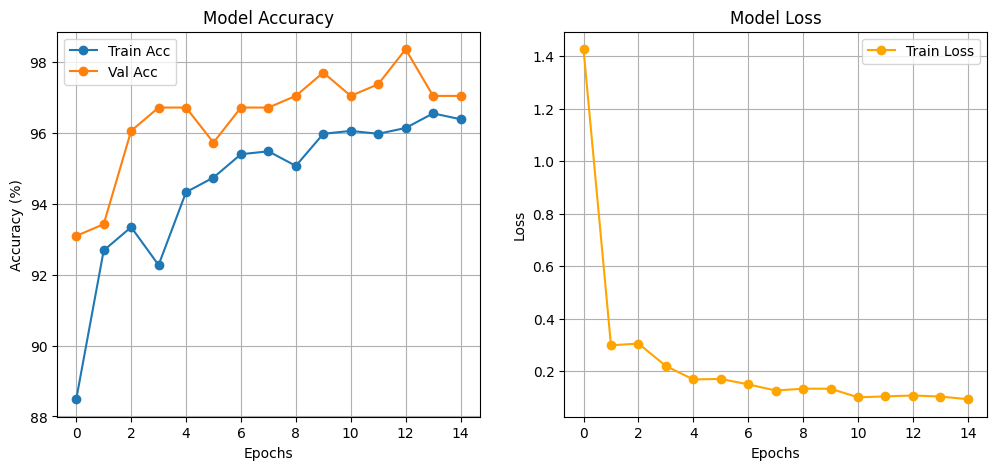

In [5]:
# ==========================================
# 7. RESULTS & INTERPRETATION (VALIDATION SET)
# ==========================================
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# 1. SETUP & SAFETY CHECKS
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

if 'trained_model' not in locals() or 'val_loader' not in locals():
    print("❌ Error: 'trained_model' or 'val_loader' not found. Please run training first.")
else:
    # 2. LEARNING CURVES
    if 'history' in locals() and history: 
        plt.figure(figsize=(12, 5))
        
        # Accuracy
        plt.subplot(1, 2, 1)
        plt.plot(history['train_acc'], label='Train Acc', marker='o')
        plt.plot(history['val_acc'], label='Val Acc', marker='o')
        plt.title("Model Accuracy")
        plt.xlabel("Epochs"); plt.ylabel("Accuracy (%)")
        plt.legend(); plt.grid(True)

        # Loss
        plt.subplot(1, 2, 2)
        plt.plot(history['loss'], color='orange', label='Train Loss', marker='o')
        plt.title("Model Loss")
        plt.xlabel("Epochs"); plt.ylabel("Loss")
        plt.legend(); plt.grid(True)
        plt.show()


# grid search optimisation of other models on train set and run inference on test set 
# explain the comparision plots for bar plots for accuracy for different models and roc curves
# also visualised some random test examples

Using device: mps

--- 1. FLATTENING DATA FOR CLASSICAL MODELS ---
Training Data Shape: (1216, 49152)

--- 2. RUNNING GRID SEARCH (Optimizing Hyperparameters) ---
Training Logistic Regression... Done! Best Acc: 92.9%
Training Decision Tree... Done! Best Acc: 80.3%
Training Random Forest... Done! Best Acc: 88.8%
Training SVM... Done! Best Acc: 94.2%

--- 3. EVALUATING ON 'TESTING' FOLDER (Using Filename Labels) ---
Found 380 images in Test Set.
Processing Test Images........... Done!

--- FINAL TEST SET RESULTS ---


,Test Accuracy,AUC
Model,,
Custom Deep CNN,0.952632,0.994571
SVM,0.939474,0.974543
Logistic Regression,0.923684,0.972216
Random Forest,0.873684,0.948726
Decision Tree,0.805263,0.808130


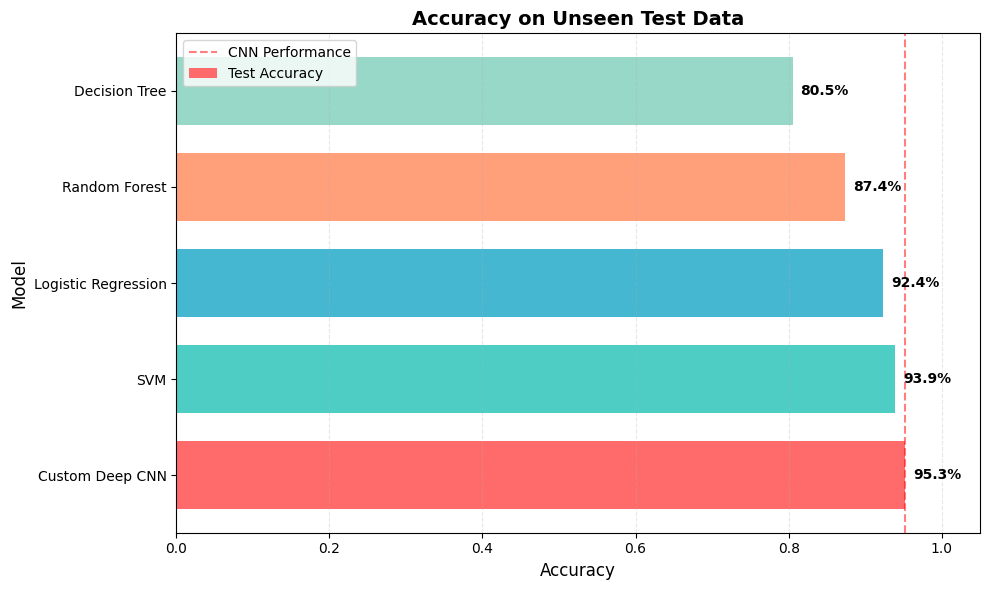

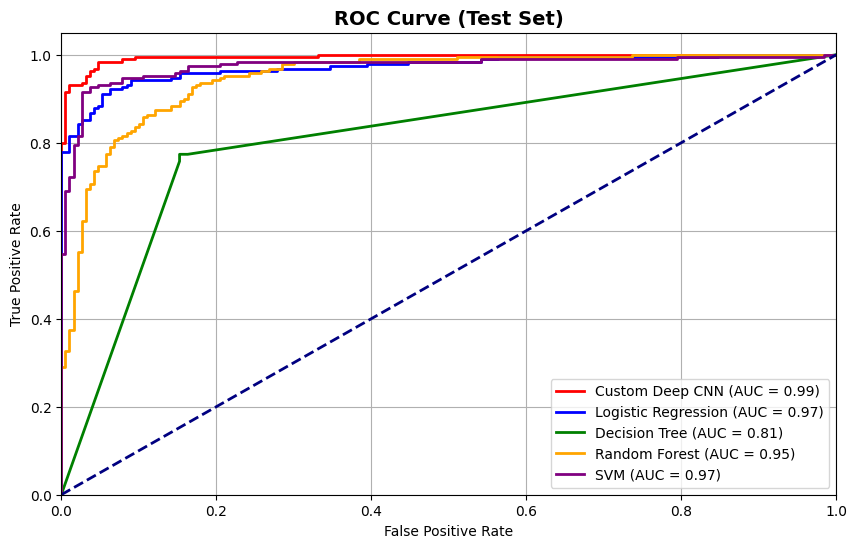


--- VISUALIZING 20 RANDOM TEST SAMPLES ---


/var/folders/zw/v7pww7t179d7swm7_6p5v2fm0000gn/T/ipykernel_11199/2451851719.py:292: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/var/folders/zw/v7pww7t179d7swm7_6p5v2fm0000gn/T/ipykernel_11199/2451851719.py:292: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/opt/homebrew/anaconda3/envs/c111/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/anaconda3/envs/c111/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


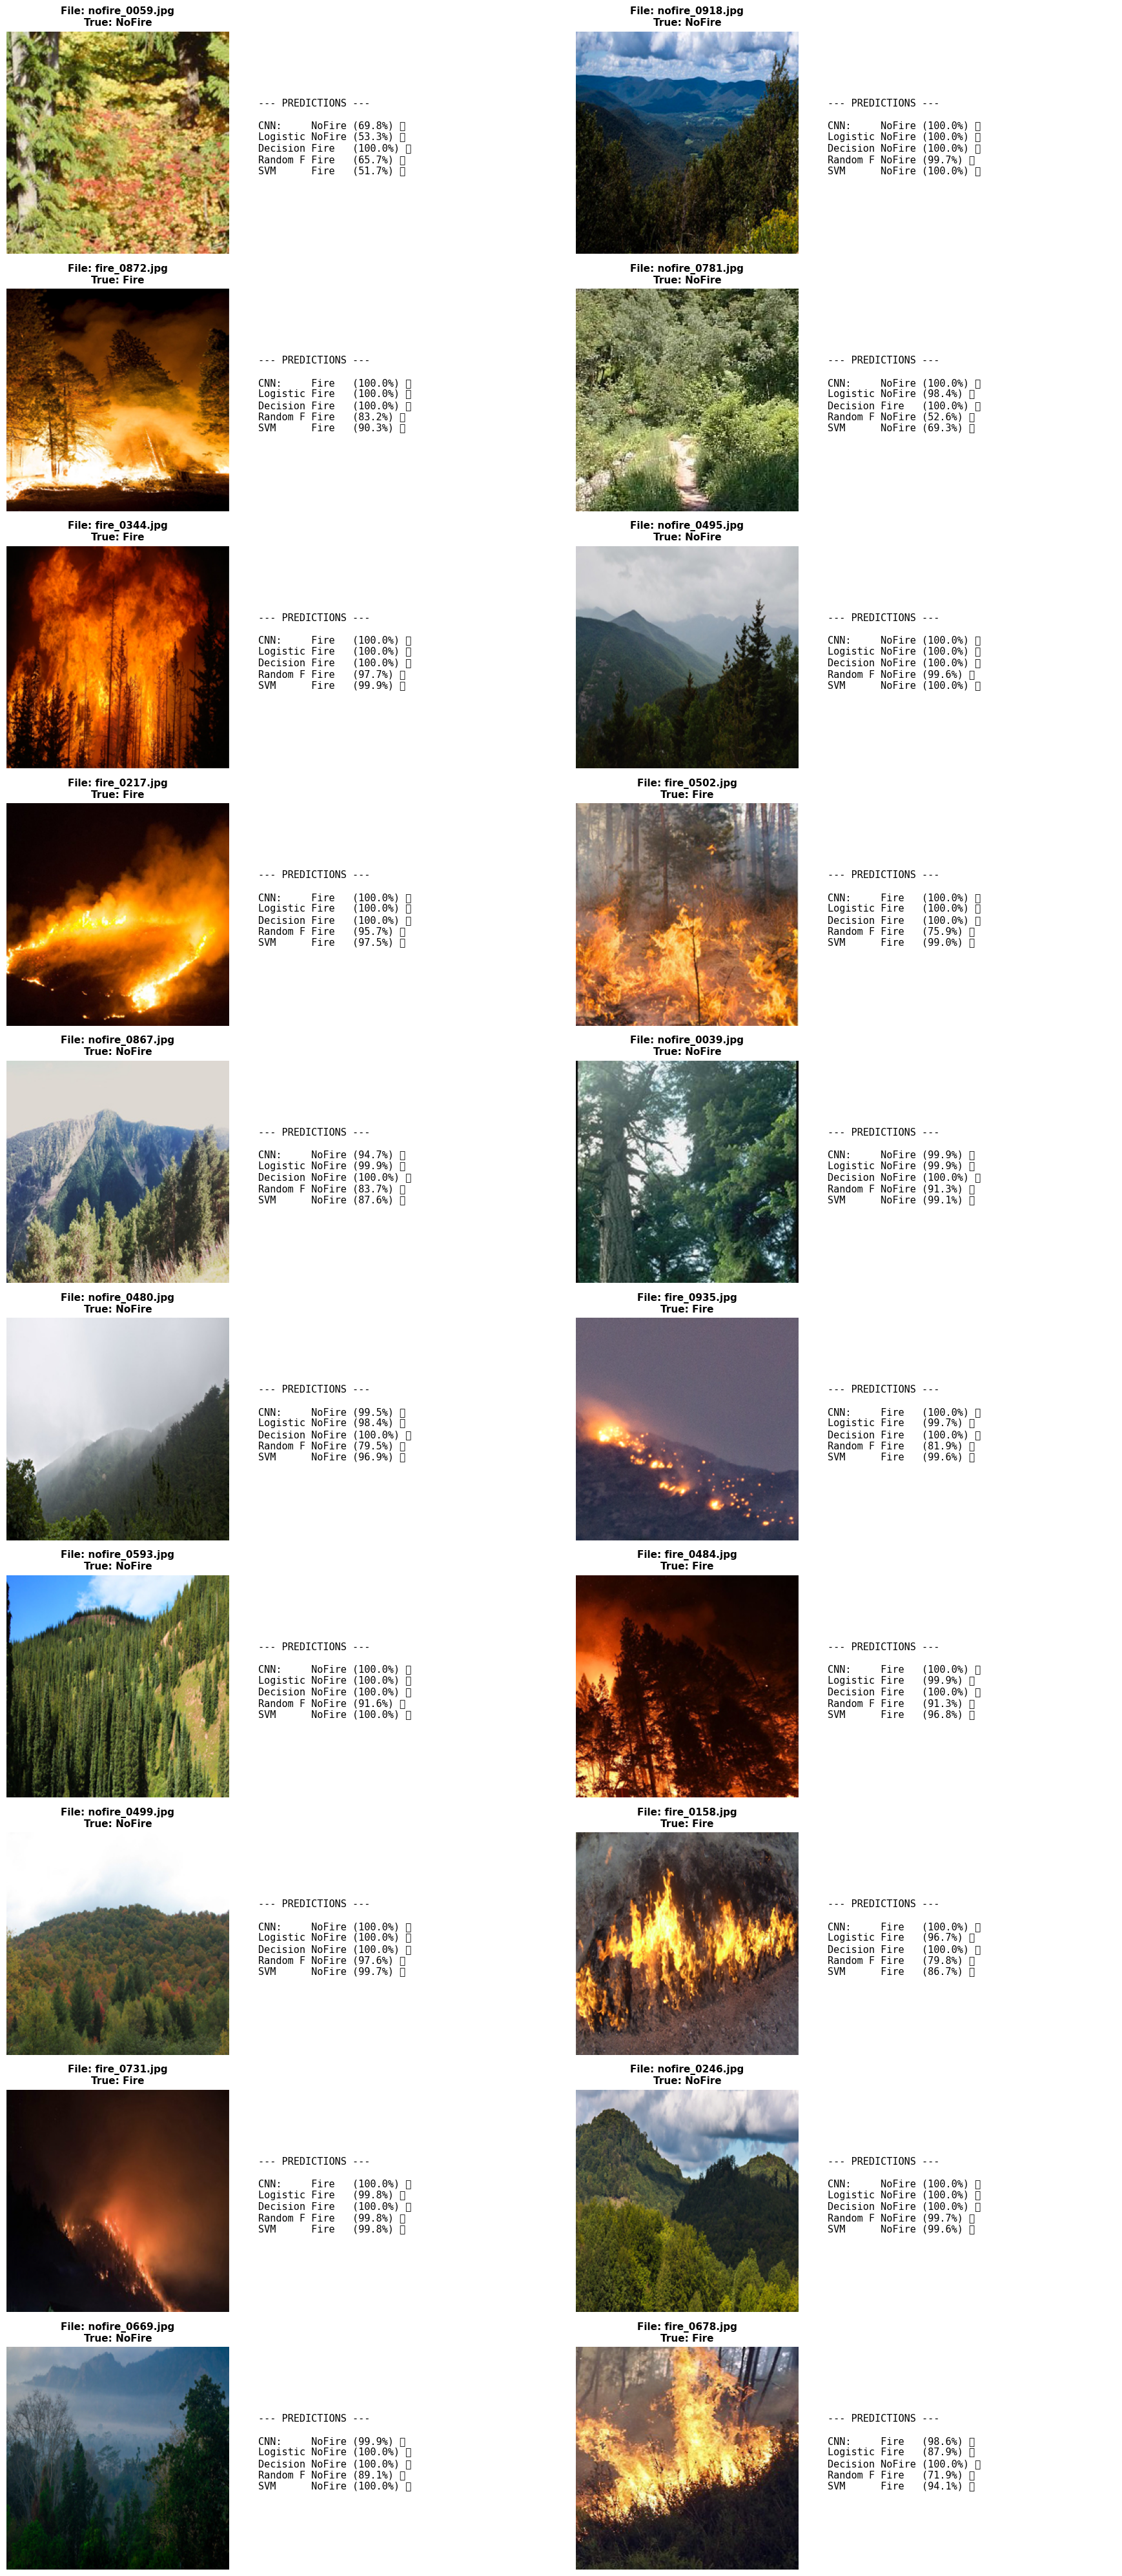

In [6]:
# ==========================================
# 8. FINAL MODEL COMPARISON (GRID SEARCH + TEST SET SCORING)
# ==========================================
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
import os
import random
from PIL import Image
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, roc_curve, auc

# 1. SETUP & CHECKS
# -----------------
if 'train_loader' not in locals() or 'trained_model' not in locals():
    raise RuntimeError("Please run Steps 1-4 (Data Loading & CNN Training) first!")

# Auto-detect device
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

# 2. PREPARE TRAINING DATA FOR CLASSICAL MODELS
# ---------------------------------------------
print("\n--- 1. FLATTENING DATA FOR CLASSICAL MODELS ---")
def get_all_data(loader):
    all_data = []
    all_labels = []
    for images, labels in loader:
        flattened = images.view(images.size(0), -1).numpy()
        all_data.append(flattened)
        all_labels.append(labels.numpy())
    return np.vstack(all_data), np.concatenate(all_labels)

X_train_flat, y_train = get_all_data(train_loader)
print(f"Training Data Shape: {X_train_flat.shape}")

# 3. GRID SEARCH (OPTIMIZATION)
# -----------------------------
model_pipeline = [
    {
        "name": "Logistic Regression",
        "model": LogisticRegression(max_iter=500, solver='liblinear'),
        "params": {"C": [0.1, 1.0]}
    },
    {
        "name": "Decision Tree",
        "model": DecisionTreeClassifier(),
        "params": {"max_depth": [10, 20], "min_samples_split": [2, 5]}
    },
    {
        "name": "Random Forest",
        "model": RandomForestClassifier(n_jobs=-1),
        "params": {"n_estimators": [50, 100], "max_depth": [10, None]}
    },
    {
        "name": "SVM",
        "model": SVC(probability=True), 
        "params": {"C": [1.0, 10.0], "kernel": ['rbf']}
    }
]

best_models = {}
print("\n--- 2. RUNNING GRID SEARCH (Optimizing Hyperparameters) ---")
for entry in model_pipeline:
    name = entry["name"]
    print(f"Training {name}...", end=" ")
    # n_jobs=-1 uses all cores for speed
    grid = GridSearchCV(entry["model"], entry["params"], cv=3, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train_flat, y_train)
    best_models[name] = grid.best_estimator_
    print(f"Done! Best Acc: {grid.best_score_:.1%}")

# 4. TEST SET EVALUATION (AUTO-GRADING)
# -------------------------------------
print("\n--- 3. EVALUATING ON 'TESTING' FOLDER (Using Filename Labels) ---")

# Locate Test Dir
TEST_DIR = None
if 'raw_path' in locals():
    for root, dirs, files in os.walk(raw_path):
        if 'Testing' in dirs:
            TEST_DIR = os.path.join(root, 'Testing')
            break

if TEST_DIR:
    test_files = [f for f in os.listdir(TEST_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    print(f"Found {len(test_files)} images in Test Set.")
    
    # Inference Transform
    inf_transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])
    
    # Storage for metrics
    y_test_true = []
    cnn_preds = []
    cnn_probs_list = [] 
    classical_preds = {name: [] for name in best_models.keys()}
    classical_probs = {name: [] for name in best_models.keys()}
    valid_files = [] 
    
    trained_model.eval()
    trained_model.to(device)
    
    # Identify Indices: Assuming Alphabetical (Fire=0, NoFire=1)
    idx_fire = 0
    idx_nofire = 1
    if 'full_dataset' in locals() and hasattr(full_dataset, 'class_to_idx'):
        idx_fire = full_dataset.class_to_idx.get('Fire', 0)
        idx_nofire = full_dataset.class_to_idx.get('NoFire', 1)
    
    print("Processing Test Images...", end="")
    for i, filename in enumerate(test_files):
        if i % 50 == 0: print(".", end="")
        
        # A. PARSE LABEL FROM FILENAME
        lower_name = filename.lower()
        if "no_fire" in lower_name or "nofire" in lower_name:
            true_label = idx_nofire
        elif "fire" in lower_name:
            true_label = idx_fire
        else:
            continue # Skip ambiguous files
            
        y_test_true.append(true_label)
        valid_files.append(filename)
        
        # Load Image
        img_path = os.path.join(TEST_DIR, filename)
        pil_img = Image.open(img_path).convert('RGB')
        img_tensor = inf_transform(pil_img)
        
        # B. CNN INFERENCE
        cnn_in = img_tensor.unsqueeze(0).to(device)
        with torch.no_grad():
            out = trained_model(cnn_in)
            probs = torch.softmax(out, dim=1)[0].cpu().numpy()
            pred = torch.argmax(out, dim=1).item()
            cnn_preds.append(pred)
            cnn_probs_list.append(probs[idx_nofire]) # Prob of Class 1 for ROC
            
        # C. CLASSICAL INFERENCE
        flat_in = img_tensor.view(-1).numpy().reshape(1, -1)
        for name, model in best_models.items():
            pred_c = model.predict(flat_in)[0]
            prob_c = model.predict_proba(flat_in)[0][idx_nofire]
            classical_preds[name].append(pred_c)
            classical_probs[name].append(prob_c)
            
    print(" Done!")
    
    # 5. METRICS & PLOTS (ACCURACY & ROC)
    # -----------------------------------
    results = []
    roc_curves = {}
    
    # CNN Metrics
    acc_cnn = accuracy_score(y_test_true, cnn_preds)
    fpr, tpr, _ = roc_curve(y_test_true, cnn_probs_list, pos_label=idx_nofire)
    auc_cnn = auc(fpr, tpr)
    roc_curves["Custom Deep CNN"] = (fpr, tpr, auc_cnn)
    results.append({"Model": "Custom Deep CNN", "Test Accuracy": acc_cnn, "AUC": auc_cnn})
    
    # Classical Metrics
    for name, preds in classical_preds.items():
        acc = accuracy_score(y_test_true, preds)
        fpr, tpr, _ = roc_curve(y_test_true, classical_probs[name], pos_label=idx_nofire)
        roc_auc = auc(fpr, tpr)
        roc_curves[name] = (fpr, tpr, roc_auc)
        results.append({"Model": name, "Test Accuracy": acc, "AUC": roc_auc})
        
    # Display Final Table
    df_test = pd.DataFrame(results).set_index("Model").sort_values("Test Accuracy", ascending=False)
    print("\n--- FINAL TEST SET RESULTS ---")
    display(df_test)
    
    # Plot 1: Colorful Accuracy Bar Chart
    plt.figure(figsize=(10, 6))
    
    # Create list of colors - one for each bar
    # We have 5 models typically: CNN, RF, SVM, LR, DT
    bar_colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8'] 
    # Or use a matplotlib colormap if number of models varies
    # bar_colors = plt.cm.viridis(np.linspace(0, 0.8, len(df_test)))
    
    # Plot bars with colors
    ax = df_test["Test Accuracy"].plot(kind='barh', color=bar_colors[:len(df_test)], width=0.7)
    
    plt.title("Accuracy on Unseen Test Data", fontsize=14, fontweight='bold')
    plt.xlabel("Accuracy", fontsize=12)
    plt.ylabel("Model", fontsize=12)
    plt.xlim(0, 1.05)
    
    # Add value labels to the end of each bar
    for i, v in enumerate(df_test["Test Accuracy"]):
        ax.text(v + 0.01, i, f"{v:.1%}", color='black', va='center', fontweight='bold')
        
    plt.axvline(x=acc_cnn, color='red', linestyle='--', alpha=0.5, label='CNN Performance')
    plt.legend()
    plt.grid(axis='x', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Plot 2: ROC Curves
    plt.figure(figsize=(10, 6))
    # Use same colors or distinct ones for lines
    line_colors = ['red', 'blue', 'green', 'orange', 'purple']
    for (name, (fpr, tpr, roc_auc)), color in zip(roc_curves.items(), line_colors):
        plt.plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title('ROC Curve (Test Set)', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right"); plt.grid(True); plt.show()

    # 6. QUALITATIVE VISUALIZATION (WITH CONFIDENCE)
    # ----------------------------------------------
    def visualize_test_predictions(test_dir, cnn_model, classical_models, files, true_labels, num_samples=20):
        # Select random samples (up to num_samples)
        count = min(num_samples, len(files))
        indices = random.sample(range(len(files)), count)
        
        # Dynamic height: 4 inches per row (2 cols -> 2 samples per row)
        rows = (count + 1) // 2
        plt.figure(figsize=(18, 4 * rows))
        
        for i, idx in enumerate(indices):
            filename = files[idx]
            true_lbl = true_labels[idx]
            label_str = "Fire" if true_lbl == idx_fire else "NoFire"
            
            # Load
            img_path = os.path.join(test_dir, filename)
            pil_img = Image.open(img_path).convert('RGB')
            img_tensor = inf_transform(pil_img)
            
            # CNN Predict
            cnn_in = img_tensor.unsqueeze(0).to(device)
            with torch.no_grad():
                out = cnn_model(cnn_in)
                probs = torch.softmax(out, dim=1)[0]
                cnn_pred = torch.argmax(probs).item()
                cnn_conf = probs[cnn_pred].item()
            
            # Plot Image
            plt.subplot(rows, 4, 2*i + 1) # Left col of the pair
            plt.imshow(pil_img)
            plt.axis('off')
            
            col = 'green' if cnn_pred == true_lbl else 'red'
            plt.title(f"File: {filename}\nTrue: {label_str}", fontsize=11, fontweight='bold')
            
            # Plot Text Report
            plt.subplot(rows, 4, 2*i + 2) # Right col of the pair
            plt.axis('off')
            
            # CNN Text
            mark = "✅" if cnn_pred == true_lbl else "❌"
            pred_str = "Fire" if cnn_pred == idx_fire else "NoFire"
            text = f"--- PREDICTIONS ---\n\n"
            text += f"CNN:     {pred_str:<6} ({cnn_conf:.1%}) {mark}\n"
            
            # Classical Text
            flat_in = img_tensor.view(-1).numpy().reshape(1, -1)
            for name, model in classical_models.items():
                pred_c = model.predict(flat_in)[0]
                prob_c_all = model.predict_proba(flat_in)[0]
                conf_c = prob_c_all[pred_c]
                
                mark_c = "✅" if pred_c == true_lbl else "❌"
                pred_str_c = "Fire" if pred_c == idx_fire else "NoFire"
                
                # Short name
                s_name = name[:8]
                text += f"{s_name:<8} {pred_str_c:<6} ({conf_c:.1%}) {mark_c}\n"
                
            plt.text(0, 0.5, text, fontsize=11, fontfamily='monospace', va='center')
            
        plt.tight_layout()
        plt.show()

    print(f"\n--- VISUALIZING {min(20, len(valid_files))} RANDOM TEST SAMPLES ---")
    visualize_test_predictions(TEST_DIR, trained_model, best_models, valid_files, y_test_true, num_samples=20)

else:
    print("Error: Could not find Testing folder.")

# explain the generated confusion matrices on test set 


--- CONFUSION MATRICES (TEST SET) ---


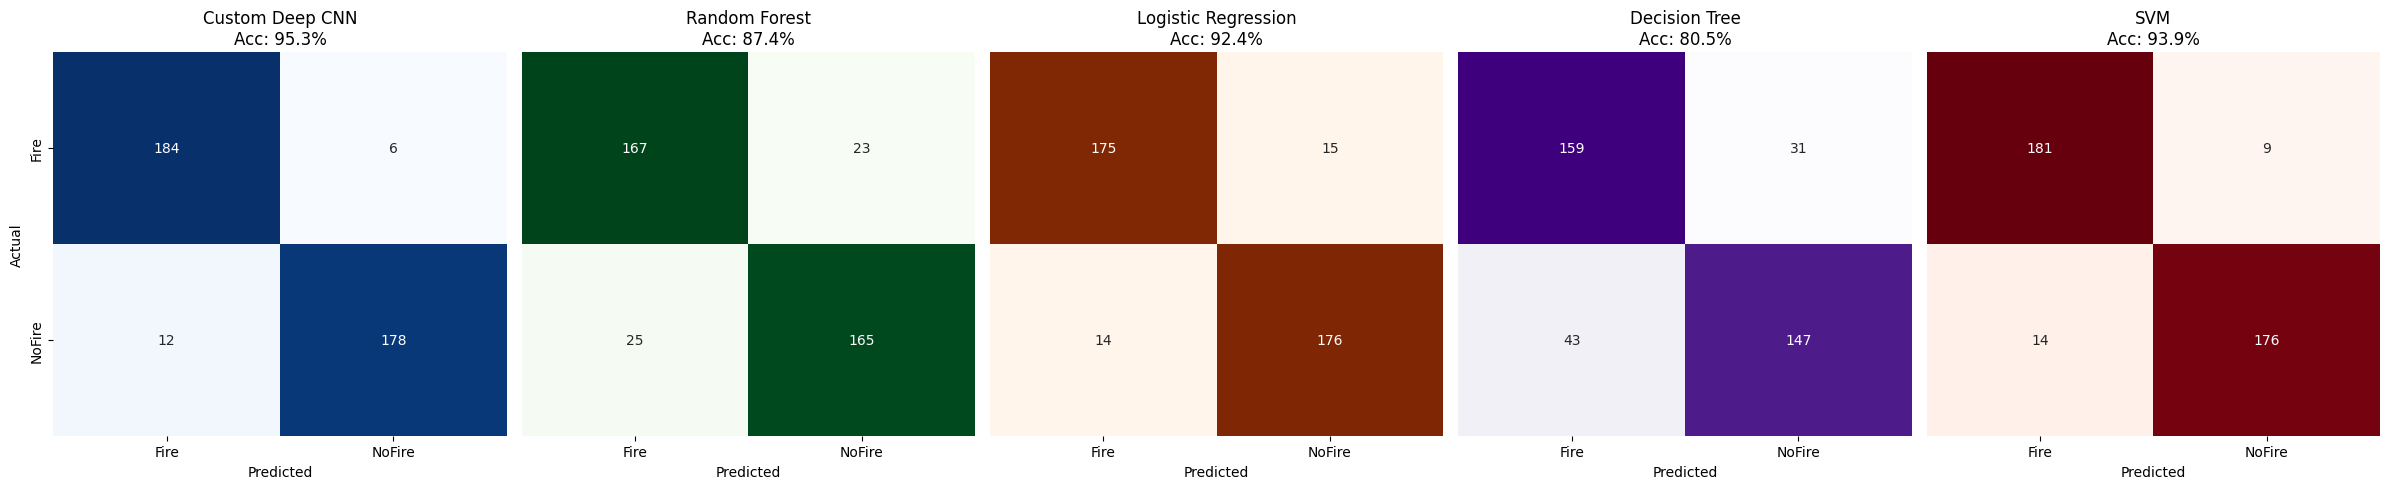

In [7]:
# ==========================================
# 11. CONFUSION MATRICES ON TEST SET (ALL MODELS)
# ==========================================
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score

def plot_test_confusion_matrices(y_true, cnn_preds, classical_preds, class_names=['Fire', 'NoFire']):
    print("\n--- CONFUSION MATRICES (TEST SET) ---")
    
    # Setup layout: 1 Row, 5 Columns (CNN + 4 Classical)
    fig, axes = plt.subplots(1, 5, figsize=(24, 5))
    
    # ---------------------------------
    # 1. Custom Deep CNN (Blue)
    # ---------------------------------
    cm_cnn = confusion_matrix(y_true, cnn_preds)
    sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=class_names, yticklabels=class_names, cbar=False)
    axes[0].set_title(f"Custom Deep CNN\nAcc: {accuracy_score(y_true, cnn_preds):.1%}")
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')
    
    # ---------------------------------
    # 2. Classical Models Loop
    # ---------------------------------
    # Define config: (Model Name, Color Map, Index)
    models_config = [
        ("Random Forest", "Greens", 1),
        ("Logistic Regression", "Oranges", 2),
        ("Decision Tree", "Purples", 3),
        ("SVM", "Reds", 4)
    ]
    
    for name, color, idx in models_config:
        if name in classical_preds:
            preds = classical_preds[name]
            cm = confusion_matrix(y_true, preds)
            
            sns.heatmap(cm, annot=True, fmt='d', cmap=color, ax=axes[idx],
                        xticklabels=class_names, yticklabels=class_names, cbar=False)
            
            axes[idx].set_title(f"{name}\nAcc: {accuracy_score(y_true, preds):.1%}")
            axes[idx].set_xlabel('Predicted')
            # Hide Y label for inner plots to look cleaner
            axes[idx].set_yticks([]) 
        else:
            axes[idx].text(0.5, 0.5, "Data Not Found", ha='center', va='center')
            axes[idx].set_title(name)

    plt.tight_layout()
    plt.show()

# Run Plotting
# Ensure these variables exist from Step 8
if 'y_test_true' in locals() and 'cnn_preds' in locals() and 'classical_preds' in locals():
    # Adjust class names if needed based on your dataset mapping
    # Usually Fire=0, NoFire=1
    plot_test_confusion_matrices(y_test_true, cnn_preds, classical_preds, class_names=['Fire', 'NoFire'])
else:
    print("Error: Prediction data not found. Please run Step 8 (Test Set Evaluation) first.")